In [1]:
from cats.cdataframe   import CDataFrame   # tool for extracting data from root files (made by your local developer, Mason Buchanan)

Welcome to JupyROOT 6.28/10


In [2]:
import matplotlib.pyplot as plt    # Matplotlib is the most common plotting package for Python

#The next line is a 'magic' command (indicated by the '%'). These tend to do useful meta things.
%matplotlib inline
#This one makes plots show up in your notebooks. (Note that you can't put comments after it on the same line!)

import pandas as pd                # Some additional data-handling tools
import numpy as np                 # "Numerical python". You need this to process data efficiently
import glob                        # Might be useful for getting files
import cdms
from rawio.IO import *             # Useful for reading binary files which contain raw pulses
import ROOT
import os,sys

CDMS = os.environ["CDMS"] # set in ~/.bash_profile
stylesheet = os.path.join(CDMS,"scripts","stylesheets","rainbow.mplstyle")
plt.style.use(stylesheet)

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
import setup
import detectorLayout

In [3]:
DMCfiles = '/scratch/user/perry5334/samples/DMC_SNOLAB_HV/HV100mm_30eV_0V_tracks/DMCOutput/DMCOutput_51241116_000000.root'

In [4]:
EventNum = 2
channum = 6

# TESSim information is stored in 'G4SimDir/g4dmcTES' tree in the DMC file. Let's store the 'Trace' field.
g4dmcTES = CDataFrame('G4SimDir/g4dmcTES', [DMCfiles])
Trace = g4dmcTES.Filter(f'EventNum=={EventNum} & ChanNum=={channum} & DataType==0').AsNumpy(['Trace'])['Trace']
Trace = np.array([max(i) - i for i in Trace]) # flip traces right-side up

Profiles = g4dmcTES.Filter(f'EventNum=={EventNum} & DataType==4 & int(ChanNum)=={channum}').AsNumpy(['Trace'])['Trace']
Profile = np.sum(Profiles, axis=0)

# Let's also store the 'ChanNum' and 'ChanName' fields..
ChanName = g4dmcTES.Filter(f'EventNum=={EventNum} & ChanNum=={channum} & DataType==0').AsNumpy(['ChanName'])['ChanName']
ChanNum  = g4dmcTES.Filter(f'EventNum=={EventNum} & ChanNum=={channum} & DataType==0').AsNumpy(['ChanNum'])['ChanNum']

# Let's also get the starting time of the TES pulse T0 and the width of the timebins BinWidths.
T0       = g4dmcTES.Filter(f'EventNum=={EventNum} & ChanNum=={channum} & DataType==0').AsNumpy(['T0'])['T0'][0]
BinWidth = g4dmcTES.Filter(f'EventNum=={EventNum} & ChanNum=={channum} & DataType==0').AsNumpy(['BinWidth'])['BinWidth'][0]
TimeBins = np.arange(T0, T0 + BinWidth * len(Trace[0]), BinWidth) * 1e-3 # ns -> us

Text(0.5, 1.0, 'PFS2 TES Response')

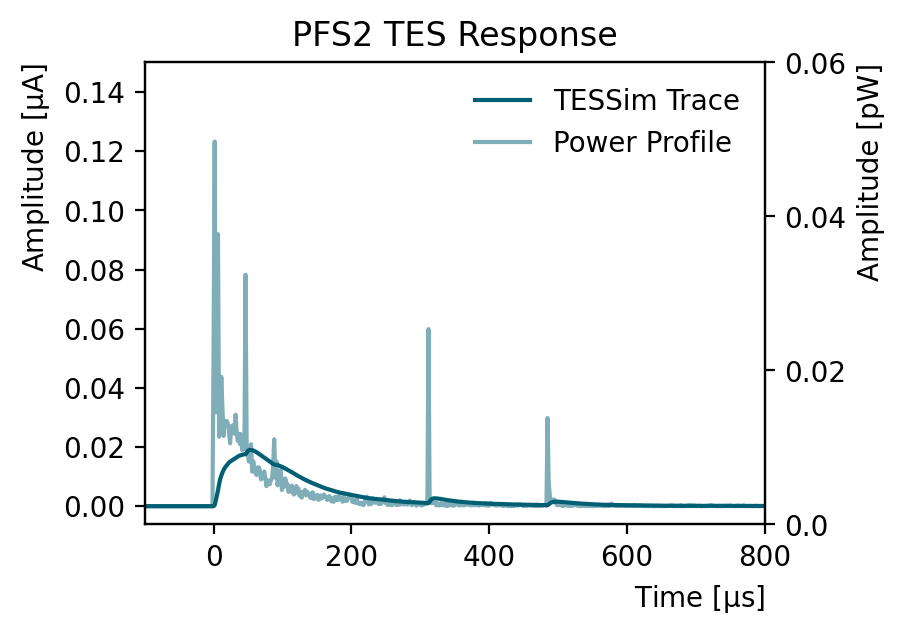

In [5]:
fig, ax1 = plt.subplots()
ax1.plot(TimeBins, Trace[0], color = 'C0', label = f'TESSim Trace')
ax1.plot(TimeBins, Profile*1e12 / sum(Profile*1e12) * sum(Trace[0]), color = 'C0', label = f'Power Profile', alpha = 0.5)

ax1.set_xlabel(r'Time [$\mathrm{\mu s}$]')
ax1.set_ylabel(r'Amplitude [$\mathrm{\mu A}$]')
ax1.set_ylim(None, 0.15)
ax1.legend(fontsize=10)

amp2pW=sum(Profile*1e12) / sum(Trace[0])

ax2 = ax1.twinx()
mn, mx = ax1.get_ylim()
ax2.set_ylim(None, 0.15)
ax2.set_yticks([0, 0.05, 0.1, 0.15]) 
ax2.set_yticklabels([np.round(i * amp2pW, 2) for i in [0, 0.05, 0.1, 0.15]])
ax2.set_xlim(-100, 800)
ax2.set_ylabel(r'Amplitude [pW]')
ax2.set_title('PFS2 TES Response')

In [6]:
params = ['X1', 'Y1', 'Z1', 'X3', 'Y3', 'Z3', 'Yield', 'Weight', 'KE', 'Time3', 'Track', 'ChanNum', 'Process', 'Weight', 'Yield', 'Parent']

mczip0 = CDataFrame('G4SimDir/mczip0', [DMCfiles])
zipdata_e = mczip0.Filter('Charge == -1').Filter('EventNum == 2').AsNumpy(params)
zipdata_h = mczip0.Filter('Charge == +1').Filter('EventNum == 2').AsNumpy(params)
zipdata_P = mczip0.Filter('Charge == 0').Filter('EventNum == 2').AsNumpy(params)

HitCounter = CDataFrame('G4SimDir/mcHitCounter', [DMCfiles])
stepdata_e = HitCounter.Filter('Charge == -1').Filter('EventNum == 2').AsNumpy(params)
stepdata_h = HitCounter.Filter('Charge == +1').Filter('EventNum == 2').AsNumpy(params)
stepdata_P = HitCounter.Filter('Charge == 0').Filter('EventNum == 2').AsNumpy(params)

In [7]:
t0 = min(zipdata_P['Time3'])*1e-3 # corresponds to t = 0 in traces.
PFS2cut_e = (np.sqrt(zipdata_e['X3']**2 + zipdata_e['Y3']**2)*1e3 < 19.592) & (zipdata_e['Z3'] < 0)
PFS2cut_h = (np.sqrt(zipdata_h['X3']**2 + zipdata_h['Y3']**2)*1e3 < 19.592) & (zipdata_h['Z3'] < 0)
PFS2cut_P = zipdata_P['ChanNum'] == 6

Text(0.5, 1.0, 'PFS2 TES Response')

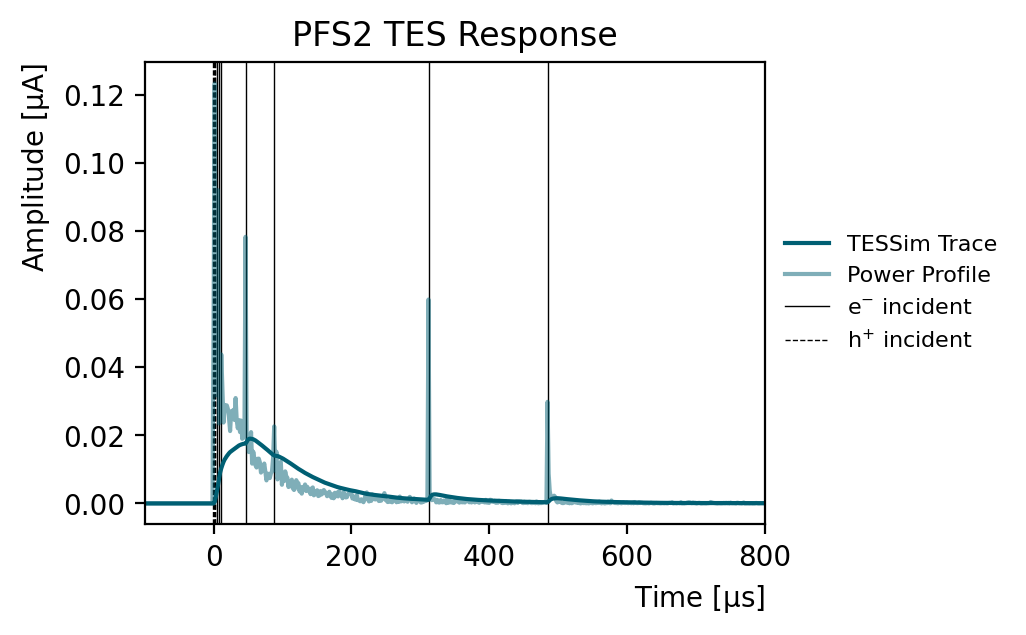

In [8]:
fig = plt.figure(figsize=(5,3))
ax = plt.subplot(111)

ax.plot(TimeBins, Trace[0], color = 'C0', label = f'TESSim Trace')
ax.plot(TimeBins, Profile*1e12 / sum(Profile*1e12) * sum(Trace[0]), color = 'C0', label = f'Power Profile', alpha = 0.5)

for i, time in enumerate(zipdata_e['Time3'][PFS2cut_e]*1e-3):
    if i == 0:
        ax.axvline(time-t0, 0, 1, color = 'black', zorder = -1000, ls = '-', lw = 0.5, label = r'e$^{-}$ incident')
    else:
        ax.axvline(time-t0, 0, 1, color = 'black', zorder = -1000, ls = '-', lw = 0.5)

for i, time in enumerate(zipdata_h['Time3'][PFS2cut_h]*1e-3):
    if i == 0:
        ax.axvline(time-t0, 0, 1, color = 'black', zorder = -1000, ls = '--', lw = 0.5, label = r'h$^{+}$ incident')
    else:
        ax.axvline(time-t0, 0, 1, color = 'black', zorder = -1000, ls = '--', lw = 0.5)

ax.set_xlabel(r'Time [$\mathrm{\mu s}$]')
ax.set_ylabel(r'Amplitude [$\mathrm{\mu A}$]')
ax.set_xlim(-100, 800)

box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

ax.set_title('PFS2 TES Response')

Text(0.5, 1.0, 'PFS2 TES Response')

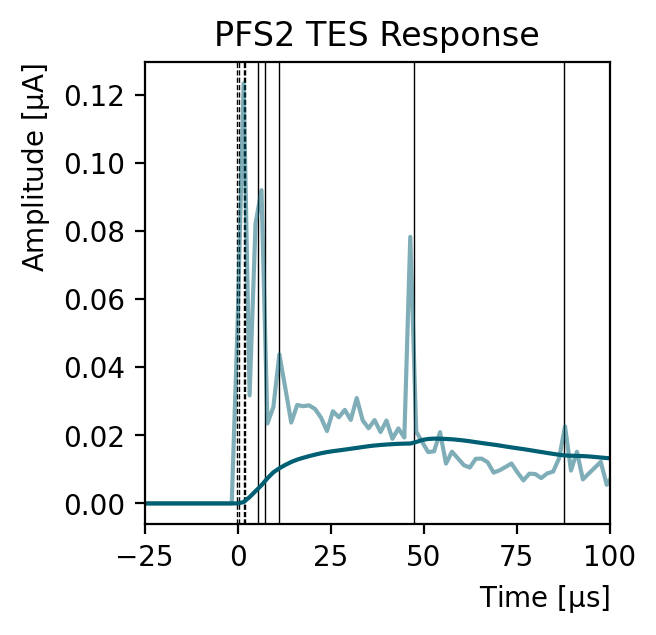

In [9]:
fig = plt.figure(figsize=(3,3))
ax = plt.subplot(111)

ax.plot(TimeBins, Trace[0], color = 'C0', label = f'TESSim Trace')
ax.plot(TimeBins, Profile*1e12 / sum(Profile*1e12) * sum(Trace[0]), color = 'C0', label = f'Power Profile', alpha = 0.5)

for i, time in enumerate(zipdata_e['Time3'][PFS2cut_e]*1e-3):
    if i == 0:
        ax.axvline(time-t0, 0, 1, color = 'black', zorder = -1000, ls = '-', lw = 0.5, label = r'e$^{-}$ incident')
    else:
        ax.axvline(time-t0, 0, 1, color = 'black', zorder = -1000, ls = '-', lw = 0.5)

for i, time in enumerate(zipdata_h['Time3'][PFS2cut_h]*1e-3):
    if i == 0:
        ax.axvline(time-t0, 0, 1, color = 'black', zorder = -1000, ls = '--', lw = 0.5, label = r'h$^{+}$ incident')
    else:
        ax.axvline(time-t0, 0, 1, color = 'black', zorder = -1000, ls = '--', lw = 0.5)

ax.set_xlabel(r'Time [$\mathrm{\mu s}$]')
ax.set_ylabel(r'Amplitude [$\mathrm{\mu A}$]')
ax.set_xlim(-25, 100)

ax.set_title('PFS2 TES Response')

In [10]:
g4dmcHits = CDataFrame('G4SimDir/g4dmcHits', DMCfiles)
hitsData = g4dmcHits.Filter('EventNum == 2').AsNumpy(['X', 'Y', 'Z', 'Time'])

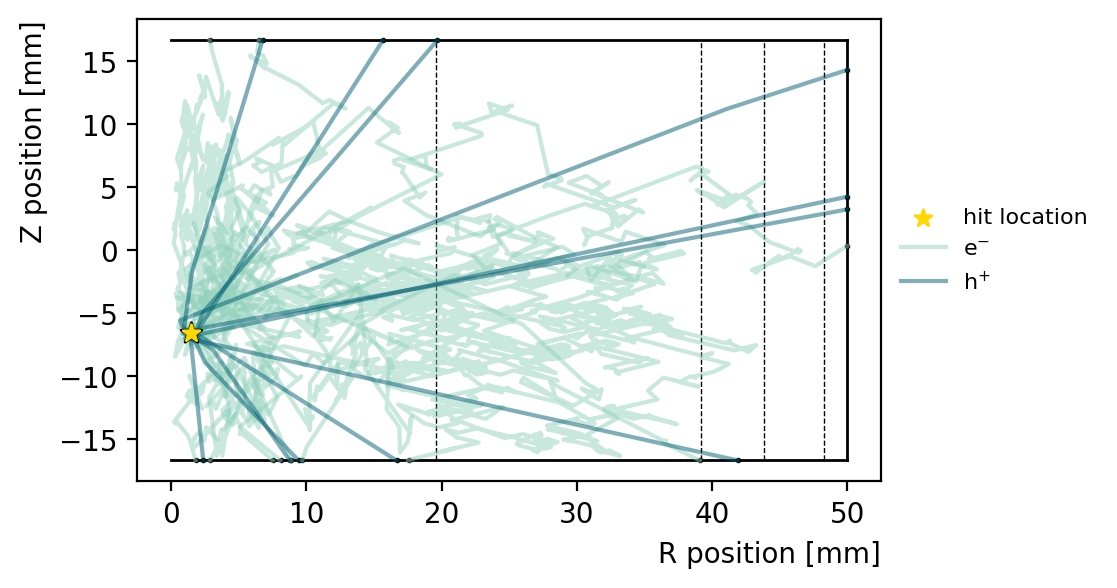

In [11]:
fig = plt.figure(figsize=(6,3))
ax = plt.subplot(111)

ax.scatter(np.sqrt((hitsData['X']*1e3)**2 + (hitsData['Y']*1e3)**2), hitsData['Z']*1e3, marker = '*', color = 'black', zorder = 20, s = 60)
ax.scatter(np.sqrt((hitsData['X']*1e3)**2 + (hitsData['Y']*1e3)**2), hitsData['Z']*1e3, marker = '*', color = 'gold', zorder = 20, s = 40, label = 'hit location')

ax.plot([0, 50], [-33.33/2, -33.33/2], lw = 1, color = 'black')
ax.plot([0, 50], [33.33/2, 33.33/2], lw = 1, color = 'black')
ax.plot([50, 50], [-33.33/2, 33.33/2], lw = 1, color = 'black')

ax.plot([19.592, 19.592], [-33.33/2, 33.33/2], lw = 0.5, ls = '--', color = 'black')
ax.plot([39.192, 39.192], [-33.33/2, 33.33/2], lw = 0.5, ls = '--', color = 'black')
ax.plot([43.818, 43.818], [-33.33/2, 33.33/2], lw = 0.5, ls = '--', color = 'black')
ax.plot([48.3, 48.3], [-33.33/2, 33.33/2], lw = 0.5, ls = '--', color = 'black')

for i, Track in enumerate(np.unique(stepdata_e['Track'])):
    TrackCut = stepdata_e['Track'] == Track
    Time = stepdata_e['Time3'][TrackCut]
    X = stepdata_e['X3'][TrackCut]*1e3
    Y = stepdata_e['Y3'][TrackCut]*1e3
    Z = stepdata_e['Z3'][TrackCut]*1e3
    R = np.sqrt(X**2 + Y**2)

    Timesort, Rsort, Zsort = zip(*sorted(zip(Time, R, Z)))

    if i == 0:
        ax.plot(Rsort, Zsort, color = 'C2', alpha = 0.5, label = r'e$^{-}$')
    else:
        ax.plot(Rsort, Zsort, color = 'C2', alpha = 0.5)
    ax.scatter([Rsort[-1]], [Zsort[-1]], color = 'black', s=1)


for i, Track in enumerate(np.unique(stepdata_h['Track'])):
    TrackCut = stepdata_h['Track'] == Track
    Time = stepdata_h['Time3'][TrackCut]
    X = stepdata_h['X3'][TrackCut]*1e3
    Y = stepdata_h['Y3'][TrackCut]*1e3
    Z = stepdata_h['Z3'][TrackCut]*1e3
    R = np.sqrt(X**2 + Y**2)

    Timesort, Rsort, Zsort = zip(*sorted(zip(Time, R, Z)))

    if i == 0:
        ax.plot(Rsort, Zsort, color = 'C0', alpha = 0.5, label = r'h$^{+}$')
    else:
        ax.plot(Rsort, Zsort, color = 'C0', alpha = 0.5)
    ax.scatter([Rsort[-1]], [Zsort[-1]], color = 'black', s=1)


ax.set_xlabel(r'R position [mm]')
ax.set_ylabel(r'Z position [mm]')

box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

In [12]:
incTracks = np.array([i in zipdata_P['Track'] for i in stepdata_P['Track']])

In [13]:
Track = np.array([j for j in stepdata_P['Track'][incTracks]])
Energy = np.array([j for j in stepdata_P['Yield'][incTracks]*stepdata_P['Weight'][incTracks]])
Process = np.array([j for j in stepdata_P['Process'][incTracks]])

In [14]:
bins = len(np.arange(0, 600, 1.6))
absorbed = {'G4CMPChargeBoundary': np.zeros(bins),
            'G4CMPChargeRecombine': np.zeros(bins),
            'G4CMPLukeScattering': np.zeros(bins),
            'G4CMPPhononBoundary': np.zeros(bins),
            'phononDownconversion': np.zeros(bins)}

for i, t in enumerate(np.arange(0, 600, 1.6)):
    
    TimeCut = (zipdata_P['Time3']*1e-3 - t0 > t) & (zipdata_P['Time3']*1e-3 - t0 < t + 1.6)
    Tracks = zipdata_P['Track'][TimeCut & PFS2cut_P]

    for Trk in Tracks:
        TrackCut = Track == Trk
        absorbed[Process[TrackCut][0]][i] += Energy[TrackCut][0]

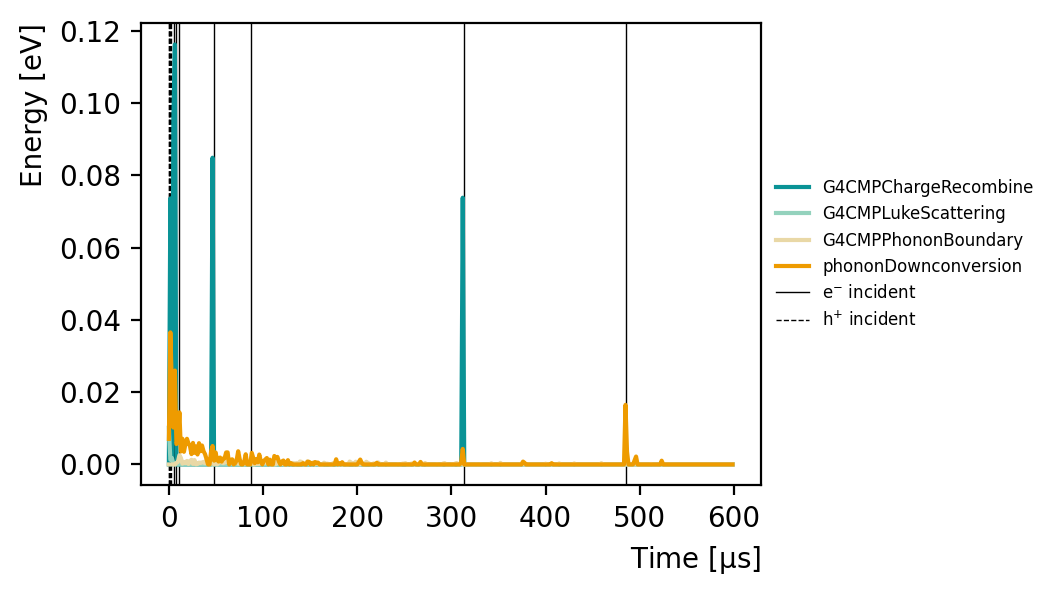

In [40]:
fig = plt.figure(figsize=(5,3), dpi = 200)
ax = plt.subplot(111)

for j, key in enumerate(list(absorbed.keys())):
    if sum(absorbed[key]) == 0:
        continue
    ax.plot(np.arange(0, 600, 1.6), absorbed[key], color = f'C{j}', label = key)

for i, time in enumerate(zipdata_e['Time3'][PFS2cut_e]*1e-3):
    if i == 0:
        ax.axvline(time-t0, 0, 1, color = 'black', zorder = -1000, ls = '-', lw = 0.5, label = r'e$^{-}$ incident')
    else:
        ax.axvline(time-t0, 0, 1, color = 'black', zorder = -1000, ls = '-', lw = 0.5)

for i, time in enumerate(zipdata_h['Time3'][PFS2cut_h]*1e-3):
    if i == 0:
        ax.axvline(time-t0, 0, 1, color = 'black', zorder = -1000, ls = '--', lw = 0.5, label = r'h$^{+}$ incident')
    else:
        ax.axvline(time-t0, 0, 1, color = 'black', zorder = -1000, ls = '--', lw = 0.5)

ax.set_xlabel(r'Time [$\mathrm{\mu s}$]')
ax.set_ylabel(r'Energy [eV]')

box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=6)

(-10.0, 100.0)

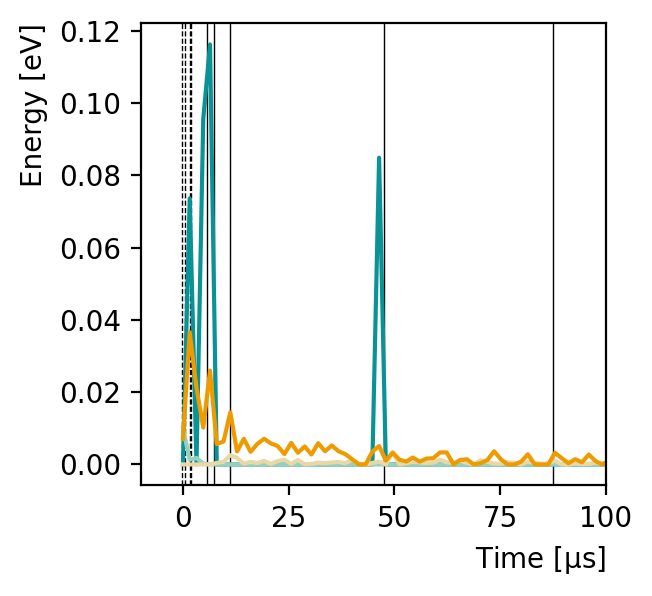

In [16]:
fig = plt.figure(figsize=(3,3), dpi = 200)
ax = plt.subplot(111)

for j, key in enumerate(list(absorbed.keys())):
    if sum(absorbed[key]) == 0:
        continue
    ax.plot(np.arange(0, 600, 1.6), absorbed[key], color = f'C{j}', label = key)

for i, time in enumerate(zipdata_e['Time3'][PFS2cut_e]*1e-3):
    if i == 0:
        ax.axvline(time-t0, 0, 1, color = 'black', zorder = -1000, ls = '-', lw = 0.5, label = r'e$^{-}$ incident')
    else:
        ax.axvline(time-t0, 0, 1, color = 'black', zorder = -1000, ls = '-', lw = 0.5)

for i, time in enumerate(zipdata_h['Time3'][PFS2cut_h]*1e-3):
    if i == 0:
        ax.axvline(time-t0, 0, 1, color = 'black', zorder = -1000, ls = '--', lw = 0.5, label = r'h$^{+}$ incident')
    else:
        ax.axvline(time-t0, 0, 1, color = 'black', zorder = -1000, ls = '--', lw = 0.5)

ax.set_xlabel(r'Time [$\mathrm{\mu s}$]')
ax.set_ylabel(r'Energy [eV]')
ax.set_xlim(-10, 100)

## Looking at second to last peak

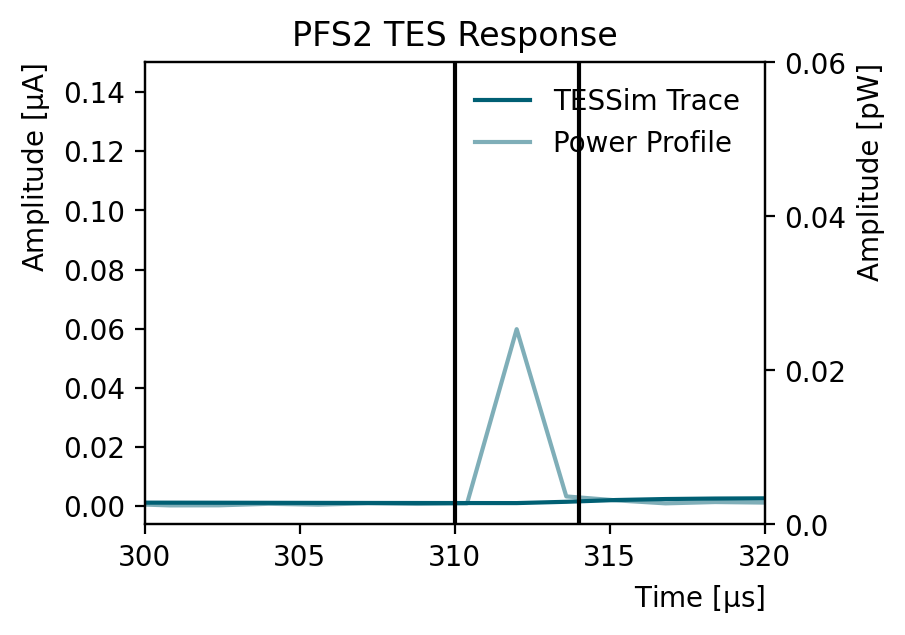

In [17]:
fig, ax1 = plt.subplots()
ax1.plot(TimeBins, Trace[0], color = 'C0', label = f'TESSim Trace')
ax1.plot(TimeBins, Profile*1e12 / sum(Profile*1e12) * sum(Trace[0]), color = 'C0', label = f'Power Profile', alpha = 0.5)

ax1.set_xlabel(r'Time [$\mathrm{\mu s}$]')
ax1.set_ylabel(r'Amplitude [$\mathrm{\mu A}$]')
ax1.set_ylim(None, 0.15)
ax1.legend(fontsize=10)

amp2pW=sum(Profile*1e12) / sum(Trace[0])

ax2 = ax1.twinx()
mn, mx = ax1.get_ylim()
ax2.set_ylim(None, 0.15)
ax2.set_yticks([0, 0.05, 0.1, 0.15]) 
ax2.set_yticklabels([np.round(i * amp2pW, 2) for i in [0, 0.05, 0.1, 0.15]])
#ax2.set_xlim(-100, 800)
ax2.set_ylabel(r'Amplitude [pW]')
ax2.set_title('PFS2 TES Response')

ax2.set_xlim(300, 320)
ax2.axvline(310, 0, 1, color = 'black')
ax2.axvline(314, 0, 1, color = 'black')

In [18]:
startwindow = t0 + 310
endwindow = t0 + 314
timeCut = (zipdata_P['Time3']*1e-3 >= startwindow) & (zipdata_P['Time3']*1e-3 <= endwindow) & PFS2cut_P

for i in range(sum(timeCut)):
    TrackCut = stepdata_P['Track'] == zipdata_P['Track'][timeCut][i]
    print(f"Track: {stepdata_P['Track'][TrackCut][-1]}, Process: {stepdata_P['Process'][TrackCut][-1]}, Energy: {stepdata_P['Yield'][TrackCut][-1]*stepdata_P['Weight'][TrackCut][-1]:.3e}")

Track: 31026.0, Process: phononDownconversion, Energy: 9.188e-04
Track: 52490.0, Process: phononDownconversion, Energy: 6.953e-04
Track: 50147.0, Process: G4CMPPhononBoundary, Energy: 1.082e-04
Track: 18296.0, Process: G4CMPPhononBoundary, Energy: 6.405e-05
Track: 72730.0, Process: G4CMPPhononBoundary, Energy: 3.354e-04
Track: 11215.0, Process: G4CMPPhononBoundary, Energy: 4.180e-06
Track: 37638.0, Process: G4CMPPhononBoundary, Energy: 2.437e-04
Track: 78289.0, Process: G4CMPPhononBoundary, Energy: 4.404e-05
Track: 33124.0, Process: G4CMPPhononBoundary, Energy: 2.654e-06
Track: 1101.0, Process: G4CMPPhononBoundary, Energy: 1.030e-04
Track: 62110.0, Process: G4CMPPhononBoundary, Energy: 2.356e-04
Track: 6142.0, Process: G4CMPPhononBoundary, Energy: 5.557e-04
Track: 190.0, Process: G4CMPPhononBoundary, Energy: 3.004e-05
Track: 76868.0, Process: phononDownconversion, Energy: 1.150e-03
Track: 61706.0, Process: G4CMPPhononBoundary, Energy: 2.019e-04
Track: 63976.0, Process: phononDownconver

In [19]:
def pathlength(dic, cut):
    if cut == None:
        cut = np.full(len(dic['X1']), True)
        
    X = np.concatenate([ [dic['X1'][cut][i], dic['X3'][cut][i]] for i in range(len(dic['X1'][cut]))]) * 1e3
    Y = np.concatenate([ [dic['Y1'][cut][i], dic['Y3'][cut][i]] for i in range(len(dic['Y1'][cut]))]) * 1e3
    Z = np.concatenate([ [dic['Z1'][cut][i], dic['Z3'][cut][i]] for i in range(len(dic['Z1'][cut]))]) * 1e3
    R = np.sqrt(X**2 + Y**2)

    return X, Y, Z, R

(-17.665, -13.665)

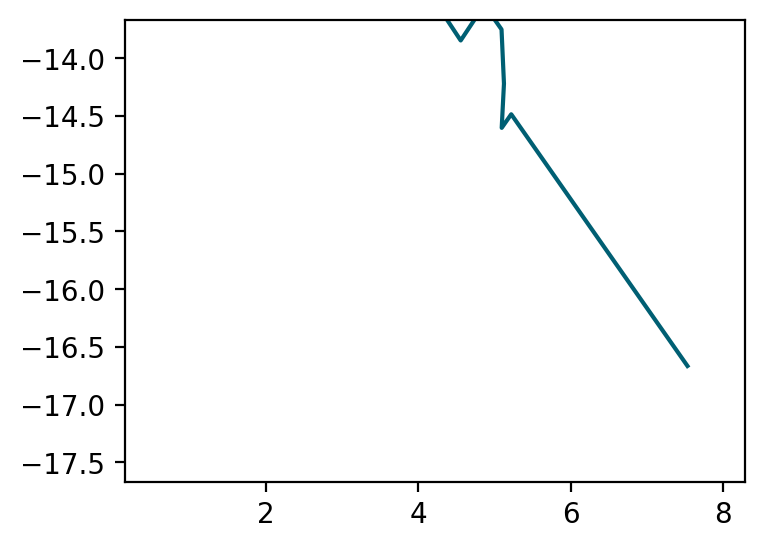

In [36]:
track = 2808.0
trackCut = stepdata_P['Track'] == track
X, Y, Z, R = pathlength(stepdata_P, trackCut)
plt.plot(R, Z, zorder = 100, color = 'red')

parent = stepdata_P['Parent'][trackCut]

while parent != 0:
    trackCut_P = stepdata_P['Track'] == parent
    trackCut_e = stepdata_e['Track'] == parent
    trackCut_h = stepdata_h['Track'] == parent

    if sum(trackCut_P != 0):
        X, Y, Z, R = pathlength(stepdata_P, trackCut_P)
        parent = stepdata_P['Parent'][trackCut_P]

    if sum(trackCut_e != 0):
        X, Y, Z, R = pathlength(stepdata_e, trackCut_e)
        parent = 0

    if sum(trackCut_h != 0):
        X, Y, Z, R = pathlength(stepdata_h, trackCut_h)
        parent = 0
    
        
    plt.plot(R, Z)

plt.ylim(-33.33/2-1, -33.33/2 + 3)
#plt.xlim(7.52928 + 32e-7, 7.52928 + 42e-7)

Text(0, 1, 'Y position [mm]')

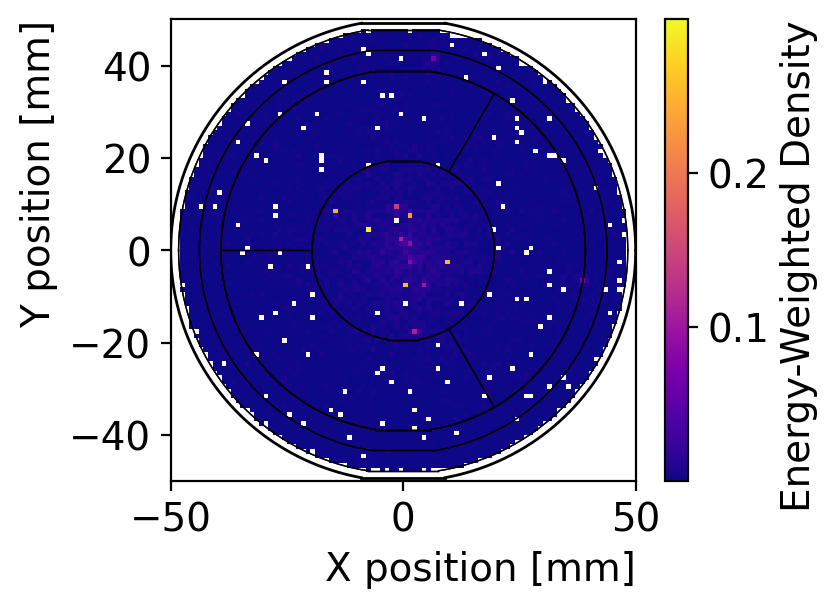

In [18]:
plt.figure(figsize=(3.75,3), dpi=200)
t0 = min(zipdata['Time3'])
startwindow = t0 + 57e3
endwindow = t0 + 63e3

cuts = (zipdata['Z3'] < 0)

# Create 2D histogram
hist, xedges, yedges = np.histogram2d(zipdata['X3'][cuts]*1e3, zipdata['Y3'][cuts]*1e3, 
                                      bins=[np.linspace(-50, 50, 101), np.linspace(-50, 50, 101)], 
                                      weights = (zipdata['Yield']*zipdata['Weight'])[cuts])

# Mask bins with zero counts
hist = np.ma.masked_where(hist == 0, hist)

# Plot the 2D histogram with masked bins
plt.pcolormesh(xedges, yedges, hist.T, cmap='plasma')

# Set the color of masked bins to white
plt.gca().patch.set_color('white')

# Add color bar to show the density scale
plt.colorbar(label='Energy-Weighted Density')

detectorLayout.drawDetOutline(DMCfiles, color='black', lw = 1, ls = '-')
detectorLayout.drawChanOutline(DMCfiles, color='black', side=1, chantype=1, labels=0, lw = 0.5, ls = '-')

plt.xlabel('X position [mm]')
plt.ylabel('Y position [mm]')
#plt.xlim(0, 10)
#plt.ylim(-10, 0)

In [ ]:
plt.figure(figsize=(3.75,3), dpi=200)
t0 = min(zipdata['Time3'])
startwindow = t0 + 281e3
endwindow = t0 + 287e3

cuts = (zipdata['Z3'] > 0) & (zipdata['Time3'] >= startwindow) & (zipdata['Time3'] <= endwindow)

# Create 2D histogram
hist, xedges, yedges = np.histogram2d(zipdata['X3'][cuts]*1e3, zipdata['Y3'][cuts]*1e3, 
                                      bins=[np.linspace(-50, 50, 101), np.linspace(-50, 50, 101)], 
                                      weights = (zipdata['Yield']*zipdata['Weight'])[cuts])

# Mask bins with zero counts
hist = np.ma.masked_where(hist == 0, hist)

# Plot the 2D histogram with masked bins
plt.pcolormesh(xedges, yedges, hist.T, cmap='plasma')

# Set the color of masked bins to white
plt.gca().patch.set_color('white')

# Add color bar to show the density scale
plt.colorbar(label='Energy-Weighted Density')

detectorLayout.drawDetOutline(DMCfiles, color='black', lw = 1, ls = '-')
detectorLayout.drawChanOutline(DMCfiles, color='black', side=1, chantype=1, labels=0, lw = 0.5, ls = '-')

plt.xlabel('X position [mm]')
plt.ylabel('Y position [mm]')
#plt.xlim(0, 10)
#plt.ylim(-10, 0)